# Import Necessary Libraries

This cell imports all the required Python libraries and modules for data manipulation, machine learning model training, evaluation, visualization, model persistence, and explainability.

**Code Functionality:**

* `import pandas as pd`: Imports the pandas library, commonly used for data manipulation and analysis, aliased as `pd`.
* `from IPython.display import display`: Imports the `display` function from `IPython.display`, useful for rendering DataFrames and other objects nicely in environments like Jupyter notebooks.
* `import numpy as np`: Imports the numpy library, essential for numerical operations, especially array and matrix manipulations, aliased as `np`.
* `from sklearn.model_selection import train_test_split`: Imports the `train_test_split` function from scikit-learn, used for splitting datasets into training and testing subsets.
* `from sklearn.feature_extraction.text import TfidfVectorizer`: Imports `TfidfVectorizer` from scikit-learn, a tool for converting a collection of raw documents to a matrix of TF-IDF features.
* `from sklearn.ensemble import RandomForestRegressor`: Imports the `RandomForestRegressor` class from scikit-learn, an ensemble machine learning algorithm suitable for regression tasks.
* `import joblib`: Imports the `joblib` library, primarily used for saving and loading Python objects that are computationally intensive to create, such as machine learning models.
* `from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score`: Imports several regression evaluation metrics (`MAE`, `MSE`, and `R-squared`) from scikit-learn.
* `import matplotlib.pyplot as plt`: Imports the `pyplot` module from matplotlib, a foundational library for creating static, interactive, and animated visualizations in Python, aliased as `plt`.
* `import seaborn as sns`: Imports the seaborn library, which is built on top of matplotlib and provides a high-level interface for drawing attractive statistical graphics.
* `import shap`: Imports the SHapley Additive exPlanations (SHAP) library, used for model explainability.
* `import warnings`: Imports the standard Python `warnings` module, often used to manage or suppress warning messages.
* `import joblib`: Imports `joblib` again (appears to be a duplicate import, but harmless).
* `sns.set_theme(style="whitegrid")`: Sets the visual style of seaborn plots to 'whitegrid', providing a clean background with a grid.

**Purpose:**

This block ensures that all necessary software components are loaded into the current environment before proceeding with data loading, preprocessing, model building, evaluation, and analysis. Importing everything at the beginning is a standard practice in Jupyter notebooks to clearly list dependencies.

In [1]:
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
import joblib
sns.set_theme(style="whitegrid")

# Load and Perform Initial Data Inspection

This cell loads the dataset from a CSV file, sets display options for pandas, and performs initial checks on the loaded data, including viewing the first and last rows, checking data types and non-null values, and generating descriptive statistics. Error handling is included to manage potential issues during file loading.

**Code Functionality:**

* `pd.set_option('display.max_colwidth', 1000)`: Sets a pandas option to increase the maximum width for displaying column content, ensuring that long text within cells isn't truncated when displayed.
* `file_path = 'issues.csv'`: Defines a string variable `file_path` holding the name of the CSV file to be loaded.
* `try...except FileNotFoundError...except Exception as e:`: This block attempts to execute the code within the `try` block. If a `FileNotFoundError` occurs (the specified file isn't found), it prints a specific error message. If any other `Exception` occurs, it catches it and prints a general error message along with the exception details.
* `df = pd.read_csv(file_path)`: Inside the `try` block, this line attempts to read the CSV file specified by `file_path` into a pandas DataFrame named `df`.
* `print(f"\nSuccessfully loaded data from {file_path}")`: Prints a success message if the file loading is successful.
* `print("-" * 60)`: Prints a line of hyphens for visual separation.
* `print("\nDisplaying the first 5 rows:")` and `display(df.head())`: Prints a header and then displays the first 5 rows of the DataFrame using `display` for better formatting in a notebook.
* `print("\nDisplaying the last 5 rows:")` and `display(df.tail())`: Prints a header and then displays the last 5 rows of the DataFrame.
* `print("\nDisplaying DataFrame info:\n")` and `df.info()`: Prints a header and then displays a concise summary of the DataFrame, including the index dtype and column dtypes, non-null values, and memory usage.
* `print("\nDisplaying descriptive statistics:\n")` and `print(df.describe())`: Prints a header and then prints descriptive statistics (like count, mean, std, min, max, and quartiles) for the numerical columns of the DataFrame. `print()` is used here as `describe()` itself returns a DataFrame which `print()` handles effectively.
* `print("\n--- Cell Execution Complete ---")`: Prints a message indicating the successful completion of the cell's execution.

**Purpose:**

The primary purpose of this cell is to load the raw dataset into a pandas DataFrame and get a preliminary understanding of its structure, content, and basic statistical properties. This initial inspection is crucial for identifying potential issues like missing values, incorrect data types, and the range and distribution of numerical features before proceeding with data cleaning and modeling. The `try...except` block makes the loading process robust against missing files.

In [2]:
# --- Set pandas display option ---
pd.set_option('display.max_colwidth', 1000)

# --- Load the dataset ---
file_path = 'issues.csv'

try:
    df = pd.read_csv(file_path)

    print(f"\nSuccessfully loaded data from {file_path}")
    print("-" * 60)

    # --- Display the first 5 rows as a table ---
    print("\nDisplaying the first 5 rows:")
    display(df.head())

    # --- Display the last 5 rows as a table ---
    print("\nDisplaying the last 5 rows:")
    display(df.tail())

    # --- Display information about the DataFrame ---
    print("\nDisplaying DataFrame info:\n")
    df.info()

    print("-" * 60)

    # --- Display descriptive statistics ---
    print("\nDisplaying descriptive statistics:\n")
    # Use print() for describe() as it's not a table rendered by display() in the same way
    print(df.describe())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure the file is in the correct directory or provide the full path.")
except Exception as e:
    print(f"An error occurred while loading or displaying the file: {e}")

# Remember to reset the option if you don't want it to affect subsequent outputs
# pd.reset_option('display.max_colwidth')

print("\n--- Cell Execution Complete ---")


Successfully loaded data from issues.csv
------------------------------------------------------------

Displaying the first 5 rows:


,Issue ID,Type,Description,Story Points,Detailed Description
0,ISSUE-6604,Bug,Optimize database queries,2,Update relevant documentation and user guides. Ensure all edge cases are handled.
1,ISSUE-5783,Bug,Resolve security vulnerability,8,Update relevant documentation and user guides. Communicate with stakeholders about the changes. Perform regression testing to ensure no existing functionality is broken. This task requires attention to detail and thorough testing. Consider performance implications of the changes. Document the changes made in the codebase. Review the code with peers before merging. Collaborate with the QA team for testing.
2,ISSUE-6920,Bug,Improve performance,8,Update relevant documentation and user guides. Ensure compatibility with existing systems and integrations. Consider performance implications of the changes. Collaborate with the QA team for testing. Communicate with stakeholders about the changes. Perform regression testing to ensure no existing functionality is broken. This task requires attention to detail and thorough testing. Review the code with peers before merging.
3,ISSUE-6779,Bug,Fix login issue,2,Collaborate with the QA team for testing. Consider performance implications of the changes.
4,ISSUE-2462,Bug,Improve performance,5,Ensure all edge cases are handled. Update relevant documentation and user guides. Collaborate with the QA team for testing. Review the code with peers before merging. Consider performance implications of the changes.



Displaying the last 5 rows:


,Issue ID,Type,Description,Story Points,Detailed Description
195,ISSUE-6874,Story,Improve performance,5,Ensure compatibility with existing systems and integrations. Consider performance implications of the changes. Document the changes made in the codebase. Communicate with stakeholders about the changes. Collaborate with the QA team for testing.
196,ISSUE-1824,Bug,Resolve security vulnerability,3,Document the changes made in the codebase. Review the code with peers before merging. Ensure all edge cases are handled.
197,ISSUE-6587,Bug,Update documentation,3,Ensure compatibility with existing systems and integrations. Collaborate with the QA team for testing. Ensure all edge cases are handled.
198,ISSUE-4427,Story,Fix login issue,1,Ensure all edge cases are handled.
199,ISSUE-9097,Bug,Improve performance,2,Collaborate with the QA team for testing. Ensure all edge cases are handled.



Displaying DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Issue ID              200 non-null    object
 1   Type                  200 non-null    object
 2   Description           200 non-null    object
 3   Story Points          200 non-null    int64 
 4   Detailed Description  200 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.9+ KB
------------------------------------------------------------

Displaying descriptive statistics:

       Story Points
count    200.000000
mean       3.740000
std        2.575962
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        8.000000

--- Cell Execution Complete ---


# Data Preparation, Model Training, and Asset Saving

This extensive cell performs several key steps in the machine learning pipeline: preparing the data by selecting features and the target variable, handling missing values, splitting the data into training and testing sets, vectorizing the text features using TF-IDF, training a Random Forest Regressor model, and finally saving the trained model and the TF-IDF vectorizer to disk.

**Code Functionality:**

* **`--- 1. Prepare Data for ML ---`**:
    * `print("--- Preparing Data for Machine Learning ---")`: Prints a header indicating the start of the data preparation phase.
    * `try...except KeyError as e:...raise`: A `try` block attempts to select the feature column ('Detailed Description') and the target column ('Story Points'). A `KeyError` exception is caught if either column name is incorrect, printing an error message and re-raising the exception to halt execution.
    * `X = df['Detailed Description'].copy()` and `y = df['Story Points'].copy()`: Selects the 'Detailed Description' column as the feature variable `X` and the 'Story Points' column as the target variable `y`. `.copy()` is used to ensure these are independent copies and modifications to `X` or `y` don't affect the original DataFrame `df`.
    * `print("Selected 'Detailed Description' as features (X) and 'Story Points' as target (y).")`: Confirms the successful selection of features and target.
    * `initial_rows = X.shape[0]`: Stores the initial number of rows before cleaning.
    * `y = y.dropna()`: Removes rows from the target variable `y` that have missing (NaN) values.
    * `X = X.loc[y.index]`: Filters the feature variable `X` to keep only the rows corresponding to the non-missing values remaining in `y`.
    * `X = X.fillna('')`: Fills any remaining missing values in the text feature `X` with an empty string `''`. This is appropriate for text data before vectorization.
    * `y = pd.to_numeric(y, errors='coerce').dropna()`: Attempts to convert the target variable `y` to a numeric type. `errors='coerce'` will turn any values that cannot be converted into NaN, and `.dropna()` then removes these resulting NaN values.
    * `X = X.loc[y.index]`: Filters `X` again to match the indices of `y` after the numeric conversion and dropping of non-numeric or remaining NaN values.
    * `rows_after_cleaning = X.shape[0]`: Stores the number of rows after all cleaning steps.
    * `print(f"Shape after handling missing values and non-numeric Story Points: {X.shape} {y.shape}")`: Prints the shape (number of rows and columns/series) of `X` and `y` after cleaning.
    * `print(f"Dropped {initial_rows - rows_after_cleaning} rows during data cleaning.")`: Reports how many rows were removed during the cleaning process.
    * `if X.shape[0] < 2: ... raise ValueError(...)`: Checks if there are at least 2 samples remaining after cleaning, which is the minimum required for a train/test split. If not, it prints an error and raises a `ValueError` to stop execution.
    * `print("Data preparation complete.")`: Indicates the end of the data preparation phase.

* **`--- 2. Split Data ---`**:
    * `print("\n--- Splitting Data into Training and Testing Sets ---")`: Prints a header for the data splitting phase.
    * `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`: Splits the cleaned feature data `X` and target data `y` into training and testing sets. `test_size=0.2` allocates 20% of the data to the test set and 80% to the training set. `random_state=42` ensures the split is reproducible.
    * `print("Data split complete.")`: Confirms the data splitting is finished.
    * `print(f"Training set: {X_train.shape[0]} samples")` and `print(f"Testing set: {X_test.shape[0]} samples")`: Prints the number of samples allocated to the training and testing sets.

* **`--- 3. Vectorize Text Data ---`**:
    * `print("\n--- Vectorizing Text Data using TF-IDF ---")`: Prints a header for the text vectorization phase.
    * `tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')`: Initializes a `TfidfVectorizer`. TF-IDF converts text into numerical feature vectors based on the frequency of words, weighted by how common they are across all documents. `max_features=5000` limits the vocabulary size to the 5000 most frequent terms. `stop_words='english'` removes common English words (like 'the', 'a', 'is') that are usually not informative.
    * `X_train_vectorized = tfidf_vectorizer.fit_transform(X_train)`: Fits the vectorizer on the training text data (`X_train`) to learn the vocabulary and IDF values, and then transforms the training data into a sparse matrix of TF-IDF features.
    * `X_test_vectorized = tfidf_vectorizer.transform(X_test)`: Transforms the testing text data (`X_test`) using the *already fitted* vectorizer. It's crucial *not* to call `fit()` on the test data to prevent data leakage from the test set into the training process.
    * `print("Text data vectorization complete.")`: Confirms text vectorization is complete.
    * `print(f"Training data shape after vectorization: {X_train_vectorized.shape}")` and `print(f"Testing data shape after vectorization: {X_test_vectorized.shape}")`: Prints the shape of the vectorized training and testing data, showing the number of samples and the number of features (which should be up to 5000 as specified by `max_features`).

* **`--- 4. Train the Model ---`**:
    * `print("\n--- Training Machine Learning Model (Random Forest Regressor) ---")`: Prints a header for the model training phase.
    * `model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)`: Initializes a `RandomForestRegressor` model. This ensemble model builds multiple decision trees and averages their predictions. `n_estimators=100` specifies the number of trees in the forest. `random_state=42` ensures reproducibility of the model training. `n_jobs=-1` tells the model to use all available CPU cores for training, speeding up the process.
    * `model.fit(X_train_vectorized, y_train)`: Trains the `RandomForestRegressor` model using the vectorized training features (`X_train_vectorized`) and the corresponding training target values (`y_train`).
    * `print("Model training complete.")`: Confirms that model training is finished.
    * `print("\nReady to evaluate the model on the test set in the next step.")`: Indicates the next logical step in the workflow.

* **`--- 5. Save the Trained Model and Vectorizer ---`**:
    * `print("\n--- Saving Trained Model and Vectorizer ---")`: Prints a header for the saving phase.
    * `try...except Exception as e:`: A `try` block attempts to save the model and vectorizer. Any exception during saving is caught, printing an error message.
    * `joblib.dump(model, 'story_point_model.pkl')`: Uses `joblib` to save the trained `RandomForestRegressor` model object to a file named 'story\_point\_model.pkl'. This allows the trained model to be loaded later without retraining.
    * `joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')`: Uses `joblib` to save the fitted `TfidfVectorizer` object to a file named 'tfidf\_vectorizer.pkl'. This is necessary because the same vectorizer must be used to transform any new text data before making predictions with the saved model.
    * `print("Model ('story_point_model.pkl') and vectorizer ('tfidf_vectorizer.pkl') saved successfully.")`: Confirms successful saving within the `try` block.
    * `print("\n--- Cell 2 Execution Complete ---")`: Prints a final message indicating the overall completion of this cell's execution.

**Purpose:**

This cell orchestrates the core steps of building a text-based regression model. It takes the raw text descriptions and numerical targets, cleans them, transforms the text into a format suitable for machine learning (numerical vectors), trains a powerful regression model to predict 'Story Points' from the text features, and finally persists the trained model and the essential text processing step (the vectorizer) to files for later use or deployment. This prepares the necessary assets for evaluating the model's performance and making predictions on new data.

In [3]:
# --- 1. Prepare Data for ML ---
print("--- Preparing Data for Machine Learning ---")

# Select features (X) and target (y)
try:
    X = df['Detailed Description'].copy()
    y = df['Story Points'].copy()
    print("Selected 'Detailed Description' as features (X) and 'Story Points' as target (y).")
except KeyError as e:
    print(f"Error: Column {e} not found in the DataFrame. Please check your column names.")
    raise


# Handle missing values
initial_rows = X.shape[0]
y = y.dropna()
X = X.loc[y.index]

# For the feature variable 'X' (Detailed Description), fill missing with empty string
X = X.fillna('')

# This handles cases where 'Story Points' might have non-numeric entries
y = pd.to_numeric(y, errors='coerce').dropna()
X = X.loc[y.index] # Keep only the corresponding descriptions after cleaning y

rows_after_cleaning = X.shape[0]
print(f"Shape after handling missing values and non-numeric Story Points: {X.shape} {y.shape}")
print(f"Dropped {initial_rows - rows_after_cleaning} rows during data cleaning.")

# Ensure there's enough data left to proceed
if X.shape[0] < 2:
    print("Error: Not enough data remaining after cleaning to proceed with model training.")
    # You would typically stop execution here
    raise ValueError("Not enough data after cleaning")

print("Data preparation complete.")


# --- 2. Split Data ---
# Split the data into training and testing sets
print("\n--- Splitting Data into Training and Testing Sets ---")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split complete.")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


# --- 3. Vectorize Text Data ---
# Convert the text descriptions into numerical features using TF-IDF
print("\n--- Vectorizing Text Data using TF-IDF ---")

# Initialize the TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

# Fit the vectorizer on the training data
X_train_vectorized = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data using the *same* fitted vectorizer
# DO NOT fit on the test data to avoid data leakage
X_test_vectorized = tfidf_vectorizer.transform(X_test)

print("Text data vectorization complete.")
print(f"Training data shape after vectorization: {X_train_vectorized.shape}")
print(f"Testing data shape after vectorization: {X_test_vectorized.shape}")


# --- 4. Train the Model ---
print("\n--- Training Machine Learning Model (Random Forest Regressor) ---")

# Initialize the RandomForestRegressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the vectorized training features and the training target
model.fit(X_train_vectorized, y_train)

print("Model training complete.")
print("\nReady to evaluate the model on the test set in the next step.")


# --- 5. Save the Trained Model and Vectorizer ---
print("\n--- Saving Trained Model and Vectorizer ---")

try:
    # Save the model
    joblib.dump(model, 'story_point_model.pkl')

    # Save the vectorizer
    joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

    print("Model ('story_point_model.pkl') and vectorizer ('tfidf_vectorizer.pkl') saved successfully.")

except Exception as e:
    print(f"Error saving model or vectorizer: {e}")

print("\n--- Cell 2 Execution Complete ---")

--- Preparing Data for Machine Learning ---
Selected 'Detailed Description' as features (X) and 'Story Points' as target (y).
Shape after handling missing values and non-numeric Story Points: (200,) (200,)
Dropped 0 rows during data cleaning.
Data preparation complete.

--- Splitting Data into Training and Testing Sets ---
Data split complete.
Training set: 160 samples
Testing set: 40 samples

--- Vectorizing Text Data using TF-IDF ---
Text data vectorization complete.
Training data shape after vectorization: (160, 37)
Testing data shape after vectorization: (40, 37)

--- Training Machine Learning Model (Random Forest Regressor) ---
Model training complete.

Ready to evaluate the model on the test set in the next step.

--- Saving Trained Model and Vectorizer ---
Model ('story_point_model.pkl') and vectorizer ('tfidf_vectorizer.pkl') saved successfully.

--- Cell 2 Execution Complete ---


# Model Evaluation and Visualization

This cell evaluates the performance of the trained Random Forest Regressor model on the previously unseen test set. It calculates standard regression metrics and generates plots to visualize the model's predictive accuracy and the distribution of errors. Error handling is included for the prediction, metric calculation, and plotting steps.

**Code Functionality:**

* `sns.set_theme(style="whitegrid")`: Sets the visual style for seaborn plots to 'whitegrid'. (Note: This was also set in the imports cell, so this line might be redundant if the imports cell has already been run).
* **`--- 1. Make Predictions on the Test Set ---`**:
    * `print("--- Evaluating the Trained Model ---")`: Prints a header indicating the start of the evaluation process.
    * `print("Making predictions on the test set...")`: Prints a message before making predictions.
    * `try...except Exception as e:...raise`: A `try` block attempts to make predictions. If any exception occurs, it prints an error message and re-raises the exception to stop execution, as predictions are fundamental to evaluation.
    * `y_pred = model.predict(X_test_vectorized)`: Uses the trained `model` to predict the 'Story Points' (`y_pred`) for the vectorized features in the test set (`X_test_vectorized`).
    * `print("Predictions made successfully.")`: Confirms successful prediction.

* **`--- 2. Calculate Evaluation Metrics ---`**:
    * `print("\nCalculating evaluation metrics...")`: Prints a header for metric calculation.
    * `try...except Exception as e:`: A `try` block attempts to calculate evaluation metrics. Any exception is caught and reported.
    * `mae = mean_absolute_error(y_test, y_pred)`: Calculates the Mean Absolute Error (MAE) between the actual test target values (`y_test`) and the predicted values (`y_pred`). MAE measures the average magnitude of errors without considering their direction.
    * `rmse = np.sqrt(mean_squared_error(y_test, y_pred))`: Calculates the Root Mean Squared Error (RMSE). It first calculates the Mean Squared Error (MSE) using `mean_squared_error`, which averages the squares of the errors, and then takes the square root using `np.sqrt`. RMSE penalizes larger errors more heavily than MAE and is on the same scale as the target variable.
    * `r2 = r2_score(y_test, y_pred)`: Calculates the R-squared ($R^2$) score. $R^2$ represents the proportion of the variance in the dependent variable (Story Points) that is predictable from the independent variables (text features). A value of 1 indicates perfect prediction, and 0 indicates that the model explains none of the variance.
    * `print("Evaluation metrics calculated:")`, `print(f"Mean Absolute Error (MAE): {mae:.4f}")`, `print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")`, `print(f"R-squared (R2): {r2:.4f}")`: Prints the calculated metrics, formatted to four decimal places for readability.

* **`--- 3. Generate Evaluation Plots ---`**:
    * `print("\nGenerating evaluation plots...")`: Prints a header for plot generation.
    * `try...except Exception as e:`: A `try` block attempts to generate plots. Any exception during plotting is caught and reported.
    * `residuals = y_test - y_pred`: Calculates the residuals, which are the differences between the actual values (`y_test`) and the predicted values (`y_pred`). Residuals represent the errors of the model.
    * **Plot 1 (Actual vs. Predicted):**
        * `plt.figure(figsize=(8, 6))`: Creates a new matplotlib figure with a specified size.
        * `sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)`: Generates a scatter plot with actual values on the x-axis and predicted values on the y-axis. `alpha=0.6` makes the points slightly transparent.
        * `plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')`: Adds a dashed black line (`'k--'`) with a line width of 2 (`lw=2`) that represents the ideal scenario where actual values equal predicted values. This serves as a visual benchmark.
        * `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`: Sets the axis labels and plot title.
        * `plt.legend()`: Displays the legend for the ideal prediction line.
        * `plt.grid(True)`: Adds a grid to the plot for easier reading.
        * `plt.show()`: Displays the generated plot.
    * **Plot 2 (Residuals vs. Predicted):**
        * `plt.figure(figsize=(8, 6))`: Creates a new figure.
        * `sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)`: Generates a scatter plot of residuals against predicted values. This plot helps assess if errors are randomly distributed or show patterns (e.g., heteroscedasticity).
        * `plt.axhline(0, color='k', linestyle='--', lw=2)`: Adds a horizontal dashed black line at y=0, indicating where residuals are zero (perfect predictions).
        * `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`: Sets the axis labels and plot title.
        * `plt.grid(True)`: Adds a grid.
        * `plt.show()`: Displays the plot.
    * **Plot 3 (Distribution of Residuals):**
        * `plt.figure(figsize=(8, 6))`: Creates a new figure.
        * `bins = min(30, len(residuals)//5 + 1) if len(residuals) > 0 else 1`: Dynamically calculates a reasonable number of bins for the histogram based on the number of residuals, capping at 30.
        * `sns.histplot(residuals, kde=True, bins=bins)`: Generates a histogram of the residuals. `kde=True` adds a Kernel Density Estimate line, showing the smoothed distribution shape. A good model often has residuals normally distributed around zero.
        * `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`: Sets the axis labels and plot title.
        * `plt.grid(True)`: Adds a grid.
        * `plt.show()`: Displays the plot.
    * `print("Evaluation plots generated.")`: Confirms plot generation is complete.

* `print("\n--- Model Evaluation Complete ---")`: Prints a final message indicating the overall completion of the cell's execution.

**Purpose:**

This cell is crucial for understanding how well the trained model generalizes to unseen data. By calculating metrics like MAE, RMSE, and R2, and visualizing the actual vs. predicted values and the residuals, we gain insights into the model's accuracy, its typical prediction errors, and whether the errors are random or exhibit patterns, which can inform further model improvement efforts.

--- Evaluating the Trained Model ---
Making predictions on the test set...
Predictions made successfully.

Calculating evaluation metrics...
Evaluation metrics calculated:
Mean Absolute Error (MAE): 0.1167
Root Mean Squared Error (RMSE): 0.1799
R-squared (R2): 0.9943

Generating evaluation plots...


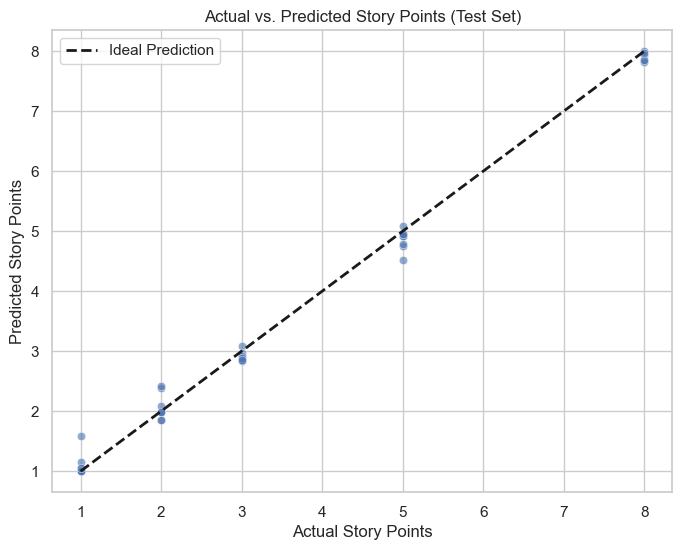

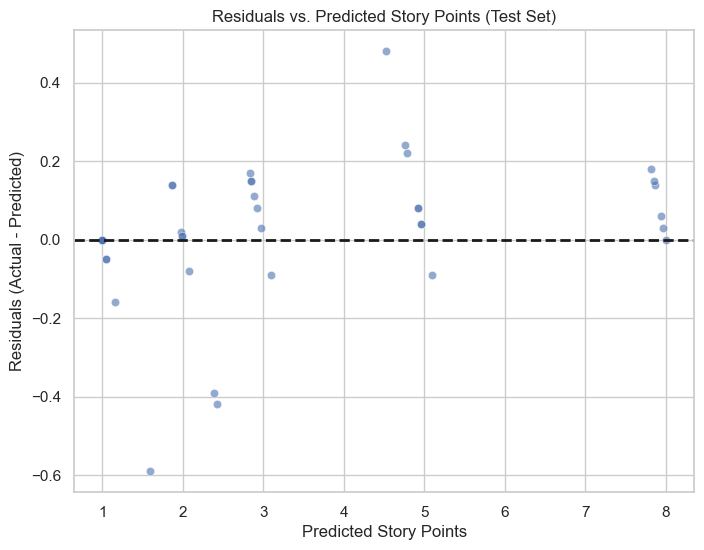

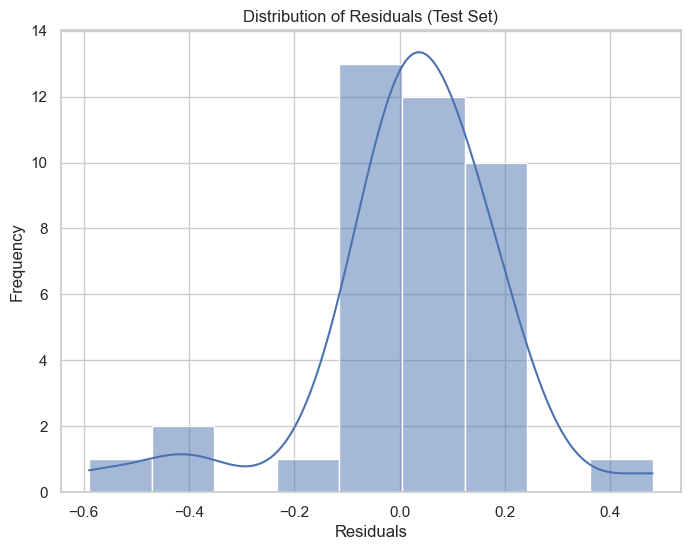

Evaluation plots generated.

--- Model Evaluation Complete ---


In [4]:
# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

# --- 1. Make Predictions on the Test Set ---
print("--- Evaluating the Trained Model ---")
print("Making predictions on the test set...")

try:
    y_pred = model.predict(X_test_vectorized)
    print("Predictions made successfully.")

except Exception as e:
    print(f"Error occurred during prediction: {e}")
    # Stop execution if predictions fail
    raise

# --- 2. Calculate Evaluation Metrics ---
print("\nCalculating evaluation metrics...")

try:
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("Evaluation metrics calculated:")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")

except Exception as e:
    print(f"Error occurred during metric calculation: {e}")

# --- 3. Generate Evaluation Plots ---
print("\nGenerating evaluation plots...")

try:
    # Calculate residuals (the errors)
    residuals = y_test - y_pred

    # Plot 1: Actual vs. Predicted Story Points
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    # Add a diagonal line where Actual == Predicted for reference
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Ideal Prediction')
    plt.xlabel("Actual Story Points")
    plt.ylabel("Predicted Story Points")
    plt.title("Actual vs. Predicted Story Points (Test Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot 2: Residuals vs. Predicted Story Points
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    # Add a horizontal line at y=0
    plt.axhline(0, color='k', linestyle='--', lw=2)
    plt.xlabel("Predicted Story Points")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.title("Residuals vs. Predicted Story Points (Test Set)")
    plt.grid(True)
    plt.show()

    # Plot 3: Distribution of Residuals
    plt.figure(figsize=(8, 6))
    # Determine bins dynamically based on data size
    bins = min(30, len(residuals)//5 + 1) if len(residuals) > 0 else 1
    sns.histplot(residuals, kde=True, bins=bins)
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Distribution of Residuals (Test Set)")
    plt.grid(True)
    plt.show()

    print("Evaluation plots generated.")

except Exception as e:
    print(f"Error occurred during plotting: {e}")

print("\n--- Model Evaluation Complete ---")

# Model Explainability with SHAP

This cell utilizes the SHAP (SHapley Additive exPlanations) library to interpret the trained Random Forest Regressor model. It calculates SHAP values for the test set, which quantify each feature's contribution to the prediction for each instance, and then generates a summary plot to visualize overall feature importance and impact across the dataset. The cell includes steps for initializing SHAP's JavaScript, preparing data for the explainer and calculations, handling potential errors, and saving the explainer object.

**Code Functionality:**

* **`shap.initjs()`**: Initializes SHAP's JavaScript library. This is necessary for rendering interactive SHAP plots correctly within a Jupyter Notebook or similar environment. A `try...except` block is included to handle potential issues during initialization.
* **`--- Preparing Data for Explainer ---`**:
    * `print("Converting full X_train_vectorized to dense array for Explainer initialization...")`: Indicates the start of preparing training data for the explainer.
    * `try...except Exception as e:...raise`: A `try` block attempts the conversion. If an error occurs, it prints an error message and re-raises the exception.
    * `X_train_full_dense_for_explainer = X_train_vectorized.toarray()`: Converts the sparse matrix representation of the training data (`X_train_vectorized`) into a dense NumPy array. Some SHAP explainers, particularly TreeExplainer with background data, perform better or require dense data.
    * `print("Conversion of training data to dense complete.")` and `print(f"Shape of dense training data for Explainer: {X_train_full_dense_for_explainer.shape}")`: Confirm the conversion and print the shape of the resulting dense array.

* **`--- 1. Initialize the SHAP Explainer ---`**:
    * `print("Initializing SHAP TreeExplainer with dense training data...")`: Prints a header for this step.
    * `try...except Exception as e:...raise`: A `try` block attempts to initialize the explainer. Errors are caught, printed along with a traceback, and then re-raised.
    * `with warnings.catch_warnings(): warnings.simplefilter("ignore")`: Temporarily suppresses warnings during the explainer initialization, as SHAP might issue warnings depending on the scikit-learn version.
    * `explainer = shap.TreeExplainer(model, X_train_full_dense_for_explainer)`: Initializes a `shap.TreeExplainer`. This explainer is specifically designed for tree-based models like Random Forests. It takes the trained `model` and the `X_train_full_dense_for_explainer` (the dense training data) as background data, which is used as a reference point for calculating feature contributions.
    * `print("SHAP TreeExplainer initialized successfully.")`: Confirms successful initialization.

* **`--- Save the SHAP Explainer ---`**:
    * `print("\n--- Saving SHAP Explainer ---")`: Prints a header for saving.
    * `try...except Exception as e:`: A `try` block attempts to save the explainer. Errors are caught and reported.
    * `joblib.dump(explainer, 'shap_explainer.pkl')`: Uses `joblib` to save the initialized SHAP explainer object to a file. Saving the explainer allows recalculating SHAP values later or using it for individual instance explanations without re-initializing it with the background data.
    * `print("SHAP Explainer ('shap_explainer.pkl') saved successfully.")`: Confirms successful saving.

* **`--- 2. Prepare Test Data for SHAP Calculation ---`**:
    * `print("\nConverting full X_test_vectorized to dense array for SHAP calculation...")`: Indicates the start of preparing test data.
    * `try...except Exception as e:...raise`: A `try` block attempts the conversion. If an error occurs, it prints an error message and re-raises the exception.
    * `X_test_full_dense_for_shap = X_test_vectorized.toarray()`: Converts the sparse matrix of test data (`X_test_vectorized`) into a dense NumPy array. This dense format is required by the explainer's `shap_values` method when using background data.
    * `print("Conversion of test data to dense complete.")` and `print(f"Shape of dense test data for SHAP: {X_test_full_dense_for_shap.shape}")`: Confirm the conversion and print the shape of the dense test array.

* **`--- 3. Calculate SHAP Values for the Full Test Set ---`**:
    * `print("Calculating SHAP values for the full test set using dense test data...")`: Prints a header for this step.
    * `try...except Exception as e:...raise`: A `try` block attempts to calculate SHAP values. Errors are caught, printed along with a traceback, and then re-raised.
    * `shap_values_full_array = explainer.shap_values(X_test_full_dense_for_shap)`: Calculates the SHAP values for every feature for every instance in the dense test set. The result is an array where each entry represents the contribution of a specific feature to the prediction of a specific test sample.
    * `print("SHAP value calculation complete.")` and `print(f"Shape of SHAP values array: {shap_values_full_array.shape}")`: Confirm calculation and print the shape of the resulting SHAP values array.

* **`--- 4. Get Feature Names ---`**:
    * `print("\nRetrieving feature names...")`: Prints a header for retrieving feature names.
    * `try...except Exception as e:`: A `try` block attempts to retrieve feature names. Errors are caught and reported.
    * `feature_names = tfidf_vectorizer.get_feature_names_out()`: Retrieves the list of learned feature names (words/terms from the vocabulary) from the fitted TF-IDF vectorizer. These names are needed for the SHAP plots.
    * `print(f"Retrieved {len(feature_names)} feature names.")`: Prints the total number of feature names retrieved.

* **`--- 5. Generate the SHAP Summary Plot ---`**:
    * `print("\nGenerating SHAP Summary Plot...")`: Prints a header for plot generation.
    * `try...except Exception as e:`: A `try` block attempts to generate the plot. Errors are caught, printed along with a traceback.
    * `shap.summary_plot(...)`: Generates the SHAP summary plot.
        * `shap_values_full_array`: The calculated SHAP values.
        * `X_test_full_dense_for_shap`: The dense test data. Used to determine the original feature values corresponding to each SHAP value (e.g., high SHAP value for a word when the word's TF-IDF score was high).
        * `feature_names=feature_names`: Provides the labels for the features on the plot.
    * `print("SHAP Summary Plot generated.")`: Confirms plot generation.

* `print("\n--- SHAP Summary Plot Generation Complete ---")`: Prints a final message indicating the overall completion of the cell's execution.

**Purpose:**

This cell provides critical insights into the model's decision-making process. The SHAP summary plot visually represents the overall importance of the top features (words in this text data) and the direction of their impact on the predicted Story Points. Each point on the plot represents a single instance from the test set, showing the feature's value (color) and its impact on the prediction (position on the x-axis). This helps understand which words are most influential in predicting higher or lower story points and how their presence/absence affects the prediction. Saving the explainer allows for more detailed analysis of individual predictions later.

Ensuring SHAP JavaScript is initialized...


SHAP JavaScript initialization command executed.

--- Generating SHAP Summary Plot for the Full Test Set ---
Converting full X_train_vectorized to dense array for Explainer initialization...
Conversion of training data to dense complete.
Shape of dense training data for Explainer: (160, 37)
Initializing SHAP TreeExplainer with dense training data...
SHAP TreeExplainer initialized successfully.

--- Saving SHAP Explainer ---
SHAP Explainer ('shap_explainer.pkl') saved successfully.
------------------------------

Converting full X_test_vectorized to dense array for SHAP calculation...
Conversion of test data to dense complete.
Shape of dense test data for SHAP: (40, 37)
Calculating SHAP values for the full test set using dense test data...
SHAP value calculation complete.
Shape of SHAP values array: (40, 37)

Retrieving feature names...
Retrieved 37 feature names.

Generating SHAP Summary Plot...


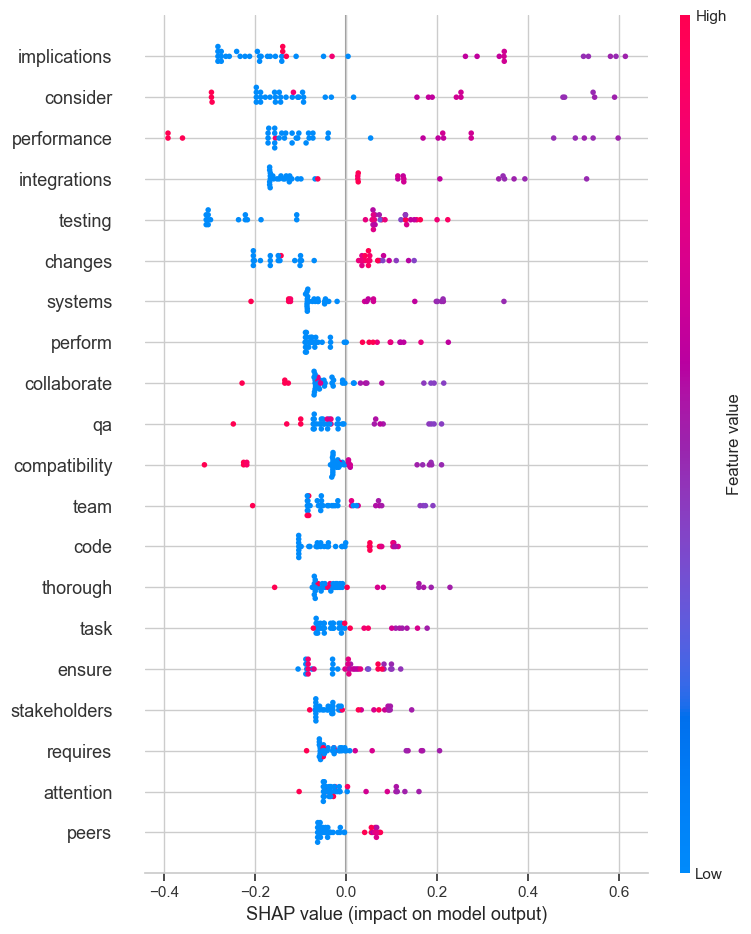

SHAP Summary Plot generated.

--- SHAP Summary Plot Generation Complete ---


In [5]:
# --- SHAP Initialization ---
print("Ensuring SHAP JavaScript is initialized...")
try:
    shap.initjs()
    print("SHAP JavaScript initialization command executed.")
except Exception as e:
    print(f"SHAP JavaScript initialization encountered an issue: {e}")
    print("SHAP plots may not render inline without successful JS initialization.")

print("\n--- Generating SHAP Summary Plot for the Full Test Set ---")

# --- PREPARE TRAINING DATA FOR EXPLAINER ---
print("Converting full X_train_vectorized to dense array for Explainer initialization...")
try:
    X_train_full_dense_for_explainer = X_train_vectorized.toarray()
    print("Conversion of training data to dense complete.")
    print(f"Shape of dense training data for Explainer: {X_train_full_dense_for_explainer.shape}")

except Exception as e:
    print(f"Error converting X_train_vectorized to dense for Explainer: {e}")
    raise


# --- 1. Initialize the SHAP Explainer ---
print("Initializing SHAP TreeExplainer with dense training data...")
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # --- CHANGE: Pass the dense training data here ---
        explainer = shap.TreeExplainer(model, X_train_full_dense_for_explainer)

    print("SHAP TreeExplainer initialized successfully.")

except Exception as e:
    print(f"Error initializing SHAP TreeExplainer: {e}")
    import traceback
    traceback.print_exc()
    raise

# --- Save the SHAP Explainer ---
print("\n--- Saving SHAP Explainer ---")
try:
    joblib.dump(explainer, 'shap_explainer.pkl')
    print("SHAP Explainer ('shap_explainer.pkl') saved successfully.")
except Exception as e:
    print(f"Error saving SHAP explainer: {e}")
print("-" * 30)


# --- 2. Prepare Test Data for SHAP Calculation ---
print("\nConverting full X_test_vectorized to dense array for SHAP calculation...")
try:
    X_test_full_dense_for_shap = X_test_vectorized.toarray()
    print("Conversion of test data to dense complete.")
    print(f"Shape of dense test data for SHAP: {X_test_full_dense_for_shap.shape}")

except Exception as e:
    print(f"Error converting X_test_vectorized to dense for SHAP calculation: {e}")
    raise


# --- 3. Calculate SHAP Values for the Full Test Set ---
print("Calculating SHAP values for the full test set using dense test data...")
try:
    # Calculate SHAP values using the dense test set data
    shap_values_full_array = explainer.shap_values(X_test_full_dense_for_shap)
    print("SHAP value calculation complete.")
    print(f"Shape of SHAP values array: {shap_values_full_array.shape}")

except Exception as e:
    print(f"Error calculating SHAP values: {e}")
    import traceback
    traceback.print_exc()
    raise


# --- 4. Get Feature Names ---
print("\nRetrieving feature names...")
try:
    feature_names = tfidf_vectorizer.get_feature_names_out()
    print(f"Retrieved {len(feature_names)} feature names.")

except Exception as e:
    print(f"Error retrieving feature names from vectorizer: {e}")


# --- 5. Generate the SHAP Summary Plot ---
print("\nGenerating SHAP Summary Plot...")
try:
    shap.summary_plot(
        shap_values_full_array,
        X_test_full_dense_for_shap, # Use the dense test data here
        feature_names=feature_names
    )
    print("SHAP Summary Plot generated.")

except Exception as e:
    print(f"Error generating SHAP Summary Plot: {e}")
    import traceback
    traceback.print_exc()


print("\n--- SHAP Summary Plot Generation Complete ---")

# Individual Prediction Explanation with SHAP Decision Plots

This cell generates SHAP Decision Plots for a specified number of random instances from the test set. Decision plots are a powerful tool for understanding how individual feature values contribute to a model's prediction for a single instance, showing the cumulative impact of features starting from the base value (average prediction) to the final prediction. The code selects random instances, retrieves their data and calculated SHAP values, and then generates and displays the decision plot for each. It also provides the original text description, actual, and predicted story points for context.

**Code Functionality:**

* `print("\n--- Generating SHAP Decision Plots for Random Instances ---")`: Prints a header indicating the start of this phase.
* `num_random_instances_to_plot = 5`: Sets a variable to control how many random instances' decision plots will be generated.
* `if X_test_full_dense_for_shap.shape[0] < num_random_instances_to_plot: ...`: Checks if the number of requested instances exceeds the total number of samples available in the test set after cleaning. If it does, it adjusts the number to plot down to the maximum available and prints a warning.
* `random_indices_full_test = np.random.choice(...)`: Randomly selects `num_random_instances_to_plot` unique indices from the available indices of the dense test data array (`X_test_full_dense_for_shap`). `replace=False` ensures that each index is chosen only once.
* `print(f"Generating Decision Plots for {num_random_instances_to_plot} random instances...")`: Confirms how many instances will be plotted.
* `expected_value = explainer.expected_value`: Retrieves the base value (also known as the expected value) from the SHAP explainer. The base value is the average model output (predicted Story Points) over the training data.
* **`for i, full_test_index in enumerate(random_indices_full_test):`**: Starts a loop that iterates through the selected random indices.
    * `print("\n" + "=" * 100)`: Prints a separator line before processing each instance.
    * `print(f"Explanation for Random Instance {i+1}/{num_random_instances_to_plot} (Index in Full Test Set Array: {full_test_index})")`: Prints information about the current instance number in the loop and its index within the dense test data array.
    * `original_test_index = X_test.index[full_test_index]`: Retrieves the original index from the DataFrame/Series (`X_test`) corresponding to this instance's position in the array. This original index is useful for looking up the original description and actual target value.
    * `instance_shap_values_array = shap_values_full_array[full_test_index]`: Extracts the array of SHAP values calculated for this specific instance from the overall `shap_values_full_array`.
    * `instance_feature_values_dense = X_test_full_dense_for_shap[full_test_index]`: Extracts the dense array of feature values for this specific instance. This is needed by the decision plot function to show the feature values associated with the SHAP contributions.
    * **`--- Generate the SHAP Decision Plot (using Matplotlib) ---`**:
        * `print("Generating SHAP Decision Plot...")`: Prints a message before generating the plot.
        * `try...except Exception as e:...`: A `try` block attempts to generate the plot. Errors are caught, reported with a traceback.
        * `shap.decision_plot(...)`: Generates the decision plot.
            * `expected_value`: The starting point of the plot (the average prediction).
            * `instance_shap_values_array`: The SHAP values for the instance, determining how the prediction path deviates from the base value.
            * `instance_feature_values_dense`: The feature values for the instance, shown alongside their contributions.
            * `feature_names=feature_names`: Provides labels for the features on the plot.
            * `show=False`: Tells SHAP *not* to display the plot immediately, allowing matplotlib commands (like setting title) to be applied before showing it.
        * `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`: Sets the title and axis labels for the matplotlib figure.
        * `plt.tight_layout()`: Adjusts plot parameters for a tight layout.
        * `plt.show()`: Displays the generated matplotlib plot.
        * `plt.close()`: Closes the current plot figure to free up memory after displaying it, preventing multiple plots from overlapping or consuming too much memory in a loop.
        * `print("SHAP Decision Plot generated and displayed.")`: Confirms plot generation.
    * **Print Contextual Information**:
        * `original_description = X_test.loc[original_test_index]`: Retrieves the original text description for the instance using its original DataFrame index.
        * `actual_story_points = y_test.loc[original_test_index]`: Retrieves the actual target value (Story Points) for the instance.
        * `predicted_story_points = y_pred[full_test_index]`: Retrieves the predicted target value for the instance using its index in the `y_pred` array.
        * `print(f"Original Description...")`, `print(...)`: Prints the original detailed description, truncated if very long.
        * `print(f"\nActual Story Points: {actual_story_points}")`: Prints the actual Story Points value.
        * `print(f"Predicted Story Points: {predicted_story_points:.2f}")`: Prints the predicted Story Points value, formatted to two decimal places.
    * `print("-" * 50)`: Prints a shorter separator line between instances.
* `print("\n--- SHAP Decision Plot Generation Complete ---")` and `print("Check the output above for the decision plots for each instance.")`: Prints final messages indicating the loop is finished and where to find the output.

**Purpose:**

This cell provides granular insights into *why* the model made a specific prediction for each chosen instance. The decision plot visualizes the path from the average predicted value (base value) to the actual prediction for the instance, showing exactly how each feature's SHAP value pushes the prediction higher or lower. Combined with the original description, actual, and predicted values, these plots help users understand the model's logic for individual cases, which is invaluable for debugging, validating, and building trust in the model.


--- Generating SHAP Decision Plots for Random Instances ---
Generating Decision Plots for 5 random instances...

Explanation for Random Instance 1/5 (Index in Full Test Set Array: 12)
Generating SHAP Decision Plot...


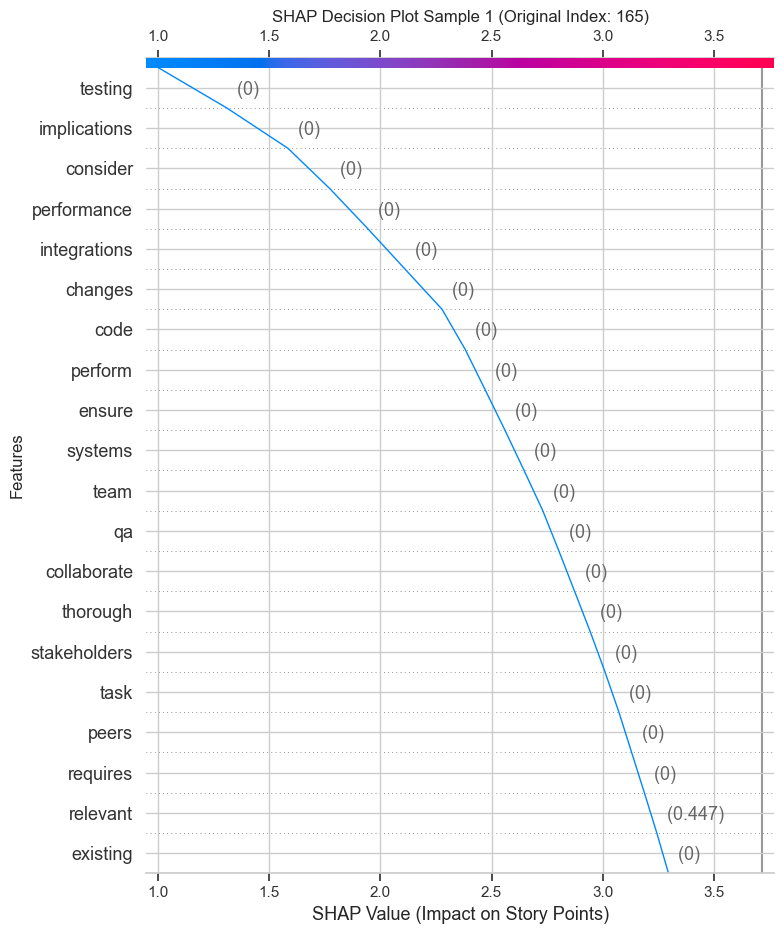

SHAP Decision Plot generated and displayed.
Original Description (Original DataFrame Index: 165):
Update relevant documentation and user guides.

Actual Story Points: 1
Predicted Story Points: 1.00
--------------------------------------------------

Explanation for Random Instance 2/5 (Index in Full Test Set Array: 7)
Generating SHAP Decision Plot...


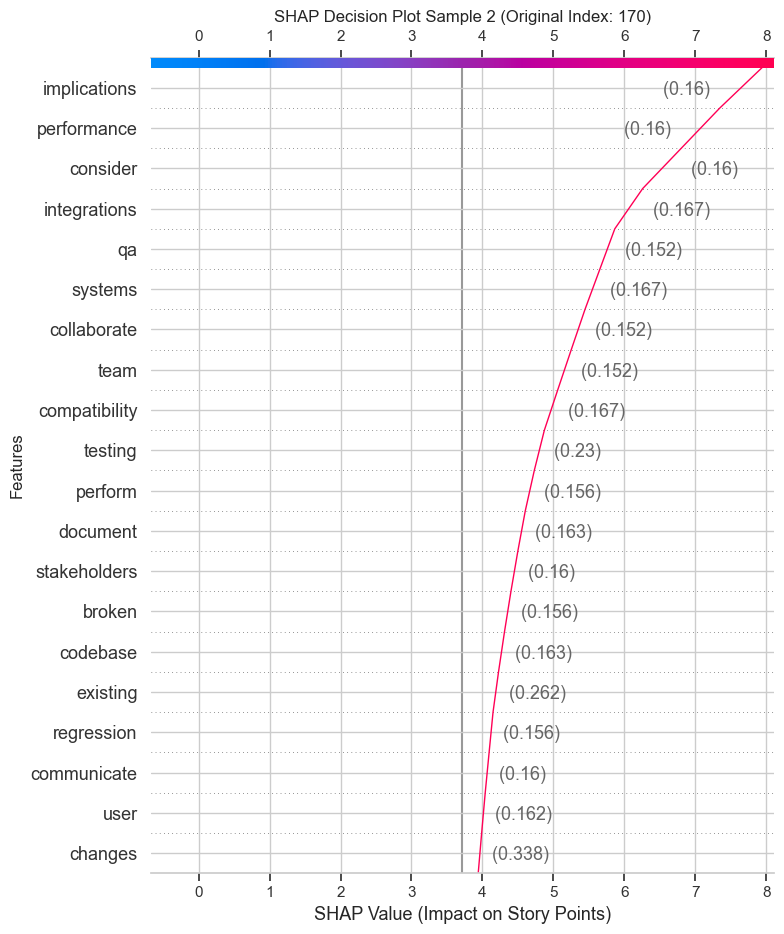

SHAP Decision Plot generated and displayed.
Original Description (Original DataFrame Index: 170):
Document the changes made in the codebase. Consider performance implications of the changes. Ensure all edge cases are handled. Update relevant documentation and user guides. Perform regression testing to ensure no existing functionality is broken. Communicate with stakeholders about the changes. Ensure compatibility with existing systems and integrations. Collaborate with the QA team for testing.

Actual Story Points: 8
Predicted Story Points: 7.94
--------------------------------------------------

Explanation for Random Instance 3/5 (Index in Full Test Set Array: 24)
Generating SHAP Decision Plot...


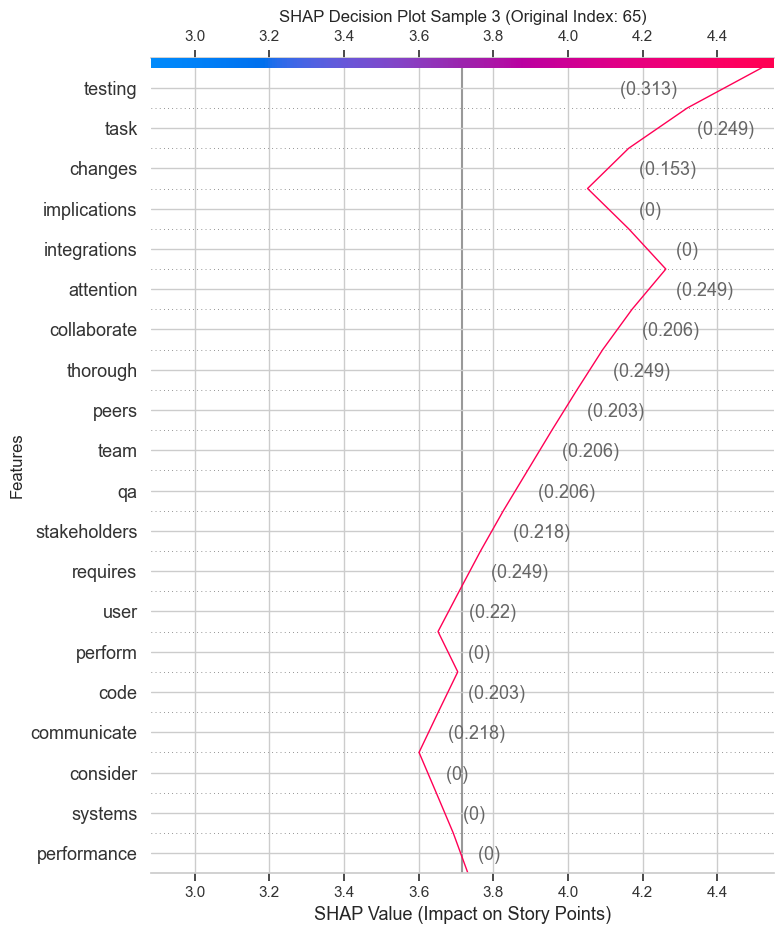

SHAP Decision Plot generated and displayed.
Original Description (Original DataFrame Index: 65):
Review the code with peers before merging. This task requires attention to detail and thorough testing. Update relevant documentation and user guides. Communicate with stakeholders about the changes. Collaborate with the QA team for testing.

Actual Story Points: 5
Predicted Story Points: 4.52
--------------------------------------------------

Explanation for Random Instance 4/5 (Index in Full Test Set Array: 18)
Generating SHAP Decision Plot...


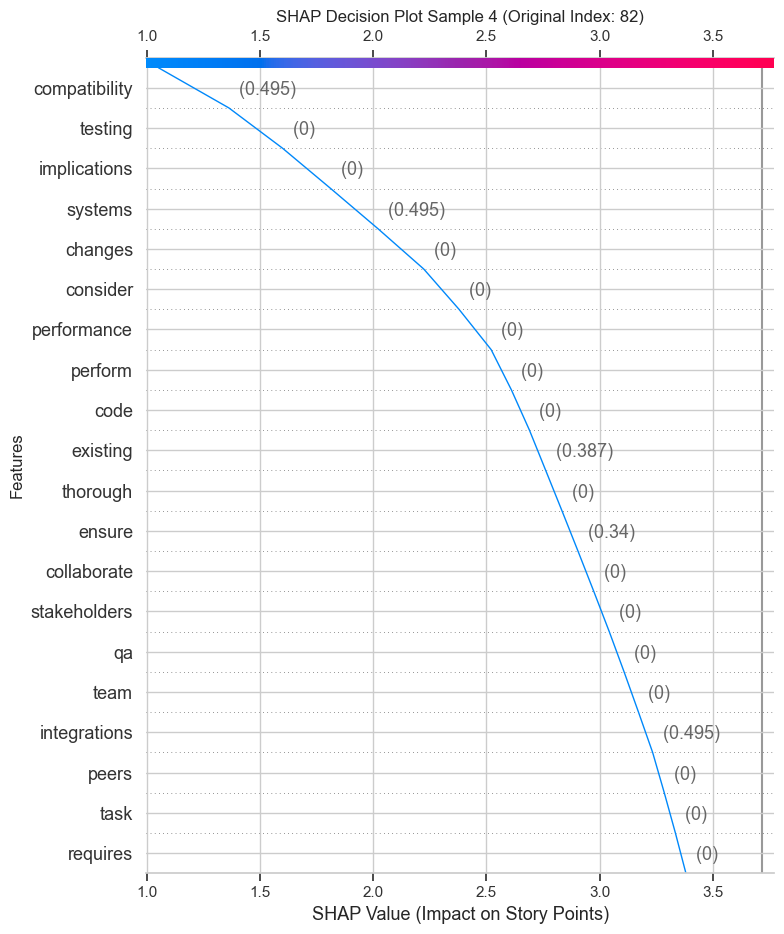

SHAP Decision Plot generated and displayed.
Original Description (Original DataFrame Index: 82):
Ensure compatibility with existing systems and integrations.

Actual Story Points: 1
Predicted Story Points: 1.05
--------------------------------------------------

Explanation for Random Instance 5/5 (Index in Full Test Set Array: 3)
Generating SHAP Decision Plot...


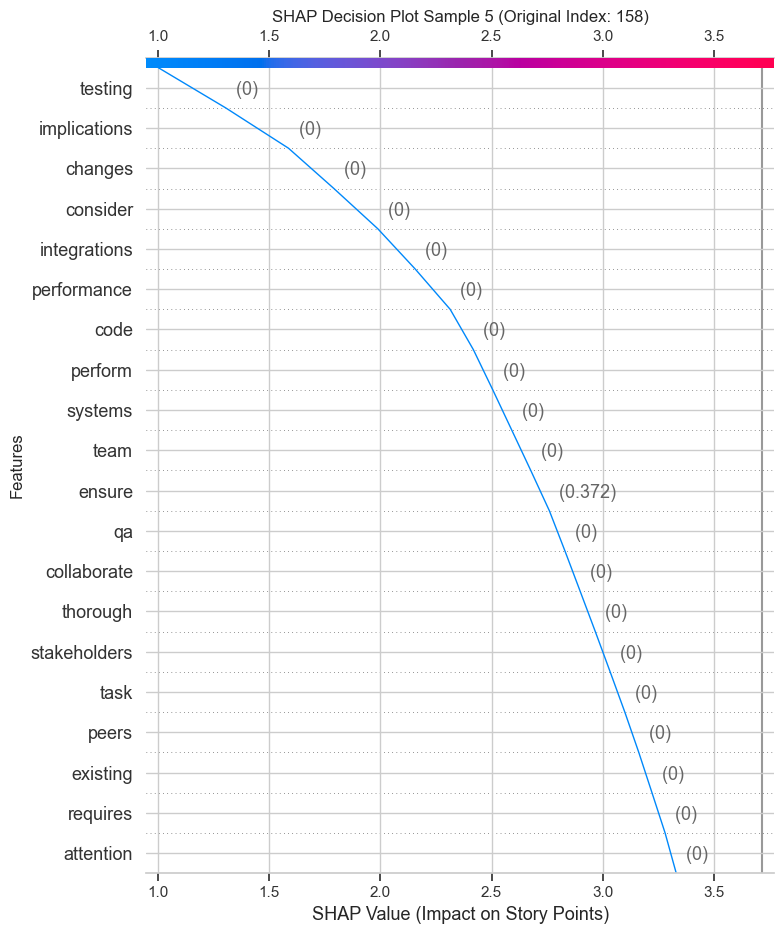

SHAP Decision Plot generated and displayed.
Original Description (Original DataFrame Index: 158):
Ensure all edge cases are handled.

Actual Story Points: 1
Predicted Story Points: 1.00
--------------------------------------------------

--- SHAP Decision Plot Generation Complete ---
Check the output above for the decision plots for each instance.


In [6]:
# --- Explanation Plots using SHAP Decision Plots ---
print("\n--- Generating SHAP Decision Plots for Random Instances ---")

num_random_instances_to_plot = 5 # Set how many random instances you want to plot

# Ensure we don't ask for more instances than available in the test set
if X_test_full_dense_for_shap.shape[0] < num_random_instances_to_plot:
     num_random_instances_to_plot = X_test_full_dense_for_shap.shape[0]
     print(f"Warning: Only {num_random_instances_to_plot} instances available in test set.")


# Get random indices from the FULL test set (indices from the X_test_full_dense_for_shap array)
random_indices_full_test = np.random.choice(X_test_full_dense_for_shap.shape[0], num_random_instances_to_plot, replace=False)

print(f"Generating Decision Plots for {num_random_instances_to_plot} random instances...")

# Get the base value (expected value) from the explainer
expected_value = explainer.expected_value

# Loop through the randomly selected indices
for i, full_test_index in enumerate(random_indices_full_test):
    print("\n" + "=" * 100)
    print(f"Explanation for Random Instance {i+1}/{num_random_instances_to_plot} (Index in Full Test Set Array: {full_test_index})")

    # Retrieve the original index from the test set split for context
    original_test_index = X_test.index[full_test_index]

    # Get the SHAP values array slice for this single instance
    instance_shap_values_array = shap_values_full_array[full_test_index]

    # Get the dense feature values for this single instance for the plot
    instance_feature_values_dense = X_test_full_dense_for_shap[full_test_index]

    # --- Generate the SHAP Decision Plot (using Matplotlib) ---
    print("Generating SHAP Decision Plot...")
    try:
        shap.decision_plot(
            expected_value,
            instance_shap_values_array,
            instance_feature_values_dense,
            feature_names=feature_names,
            show=False
        )
        # Add matplotlib elements
        plt.title(f"SHAP Decision Plot Sample {i+1} (Original Index: {original_test_index})")
        plt.xlabel("SHAP Value (Impact on Story Points)")
        plt.ylabel("Features")
        plt.tight_layout()
        plt.show()
        plt.close()

        print("SHAP Decision Plot generated and displayed.")

    except Exception as e:
        print(f"Error generating Decision Plot for instance {i+1} (Index: {full_test_index}): {e}")
        import traceback
        traceback.print_exc()


    # Get the original description and actual/predicted values for context
    original_description = X_test.loc[original_test_index]
    actual_story_points = y_test.loc[original_test_index]
    predicted_story_points = y_pred[full_test_index]

    print(f"Original Description (Original DataFrame Index: {original_test_index}):")
    print(original_description[:500] + '...' if len(original_description) > 500 else original_description)
    print(f"\nActual Story Points: {actual_story_points}")
    print(f"Predicted Story Points: {predicted_story_points:.2f}")

    print("-" * 50) # Separator for clarity between instances

print("\n--- SHAP Decision Plot Generation Complete ---")
print("Check the output above for the decision plots for each instance.")

# Load Saved Model Assets and Define Prediction Function

This cell defines the final utility function for making predictions on new, unseen detailed descriptions and includes an option to generate a SHAP explanation plot for the specific prediction. Before defining the function, it attempts to load the trained model, the fitted TF-IDF vectorizer, and the initialized SHAP explainer that were saved in the previous steps. This ensures that the function uses the exact same model and preprocessing steps as trained.

**Code Functionality:**

* `model_path = 'story_point_model.pkl'`, `vectorizer_path = 'tfidf_vectorizer.pkl'`, `explainer_path = 'shap_explainer.pkl'`: Define string variables holding the filenames of the saved model, vectorizer, and explainer files.
* **`--- Load the Saved Components ---`**:
    * `print(...)`: Prints messages indicating which files the code is attempting to load.
    * `try...except FileNotFoundError...except Exception as e:`: This `try` block attempts to load the components. It includes specific error handling for `FileNotFoundError` (if any of the `.pkl` files are missing) and a general `Exception` handler for any other loading errors. If loading fails, it prints informative error messages and sets the loaded variables to `None`.
    * `loaded_vectorizer = joblib.load(vectorizer_path)`: Loads the saved `TfidfVectorizer` object from its file using `joblib.load`.
    * `loaded_model = joblib.load(model_path)`: Loads the saved `RandomForestRegressor` model object from its file.
    * `loaded_explainer = joblib.load(explainer_path)`: Loads the saved SHAP `TreeExplainer` object from its file.
    * `feature_names = loaded_vectorizer.get_feature_names_out()`: Retrieves the list of feature names (the vocabulary terms learned by the vectorizer) from the loaded vectorizer object. These are needed for SHAP plots.
    * `print("Model, vectorizer, and explainer loaded successfully into notebook.")`: Confirms successful loading within the `try` block.
    * If loading fails, the `except` blocks print errors and set the loaded variables to `None`, indicating that the prediction function will not be able to operate.

* **`--- Define the Prediction Function with optional SHAP explanation ---`**:
    * `def predict_story_points_with_explanation(detailed_description, show_explanation=True):`: Defines a Python function named `predict_story_points_with_explanation` that takes the input text `detailed_description` and an optional boolean `show_explanation` (defaulting to `True`).
    * **Docstring (`"""Docstring goes here"""`)**: Explains the function's purpose, arguments, and return value.
    * **Inside the function:**
        * `if loaded_model is None...`: Checks if all necessary components (`model`, `vectorizer`, and `explainer`/`feature_names` if explanation is requested) were loaded successfully. If not, it returns an error string immediately.
        * `if not isinstance(detailed_description, str):`: Checks if the input `detailed_description` is a string. If not, returns an error string.
        * `processed_description = detailed_description if pd.notna(detailed_description) else ""`: Preprocesses the input string by replacing any potential NaN values with an empty string, mirroring the cleaning applied during training.
        * `try...except Exception as e:...`: A `try` block handles potential errors during text vectorization.
        * `description_vec = loaded_vectorizer.transform([processed_description])`: Transforms the *single* input description into a sparse TF-IDF vector using the *loaded* `tfidf_vectorizer`. Note that `.transform()` is used (not `.fit_transform()`) because the vectorizer was already fitted on the training data. The input description is passed as a list `[processed_description]` because the vectorizer expects an iterable.
        * `description_vec_dense = description_vec.toarray()`: Converts the resulting single-instance sparse vector into a dense NumPy array, which is required for calculating SHAP values.
        * `try...except Exception as e:...`: A `try` block handles potential errors during prediction.
        * `predicted_points = loaded_model.predict(description_vec)`: Makes a prediction on the vectorized input using the *loaded* `RandomForestRegressor` model. The prediction is returned as a NumPy array (even for a single input).
        * `prediction = predicted_points[0]`: Extracts the single predicted value from the array.
        * `if show_explanation:`: If `show_explanation` is `True`, the code block for generating the SHAP explanation is executed.
            * `print("\nGenerating SHAP explanation plot...")`: Prints a message before generating the plot.
            * `try...except Exception as e:...`: A `try` block handles potential errors during SHAP calculation or plotting, printing an error message and a traceback.
            * `shap_values_instance = loaded_explainer.shap_values(description_vec_dense)`: Calculates the SHAP values for the single input instance using the *loaded* explainer and the dense vectorized input.
            * `shap.force_plot(...)`: Generates and displays the SHAP force plot for the single instance using the Matplotlib backend.
            * `plt.show()` and `plt.close()`: Ensure the plot is displayed in the notebook output and the figure is closed afterwards to manage memory.
            * **`print("\n--- Explanation of the SHAP Force Plot ---")` and subsequent `print` statements:** **These lines print a text-based explanation of the SHAP force plot directly into the notebook output after the plot is displayed.** They describe what the base value, red/blue bars, and their lengths represent in terms of feature impact on the prediction for that specific instance.
        * `return prediction`: Returns the calculated predicted story points.

* `print("\n'predict_story_points_with_explanation' function defined.")` and `print("\nReady to make predictions and explanations in subsequent cells.")`: Print messages confirming that the function has been successfully defined and is ready for use.

**Purpose:**

This cell encapsulates the entire prediction and explanation process into a reusable function. By loading the previously saved assets, it ensures that any new input text is processed and predicted using the exact same pipeline that was trained. The function provides a convenient way to get both the predicted Story Point value and, optionally, a detailed SHAP force plot *along with a text explanation in the output*, showing which words in the description pushed the prediction higher or lower from the average. This function is designed to be used in subsequent cells with example inputs.

In [7]:
# Define the file paths for your saved model, vectorizer, and explainer
model_path = 'story_point_model.pkl'
vectorizer_path = 'tfidf_vectorizer.pkl'
explainer_path = 'shap_explainer.pkl'

# --- Load the Saved Components ---
print(f"Attempting to load components:")
print(f"- Model from '{model_path}'")
print(f"- Vectorizer from '{vectorizer_path}'")
print(f"- Explainer from '{explainer_path}'")

try:
    loaded_vectorizer = joblib.load(vectorizer_path)
    loaded_model = joblib.load(model_path)
    loaded_explainer = joblib.load(explainer_path) # Load the explainer
    feature_names = loaded_vectorizer.get_feature_names_out() # Get feature names from vectorizer
    print("Model, vectorizer, and explainer loaded successfully into notebook.")
except FileNotFoundError:
    print("Error: One or more required files (.pkl) not found.")
    print("Please make sure 'story_point_model.pkl', 'tfidf_vectorizer.pkl', and 'shap_explainer.pkl' are in the same directory as this notebook.")
    print("Ensure you have run the cells that train the model, fit the vectorizer, create the explainer, and save them.")
    loaded_vectorizer = None
    loaded_model = None
    loaded_explainer = None
    feature_names = None
except Exception as e:
    print(f"An error occurred while loading components: {e}")
    loaded_vectorizer = None
    loaded_model = None
    loaded_explainer = None
    feature_names = None


# --- Define the Prediction Function with optional SHAP explanation ---
def predict_story_points_with_explanation(detailed_description, show_explanation=True):
    """
    Predicts story points for a given detailed description using the loaded model and vectorizer,
    and optionally shows a SHAP explanation plot.

    Args:
        detailed_description (str): The text of the Jira issue's detailed description.
        show_explanation (bool): If True, generates and displays a SHAP force plot.

    Returns:
        Union[float, str]: The predicted story points as a float, or an error message string.
    """
    # Check if components were loaded successfully
    if loaded_model is None or loaded_vectorizer is None or (show_explanation and (loaded_explainer is None or feature_names is None)):
        return "Error: Model, vectorizer, or explainer failed to load. Cannot make prediction or explanation."

    if not isinstance(detailed_description, str):
        return "Error: Input must be a string."

    # Preprocess the input text - apply the SAME steps as training
    processed_description = detailed_description if pd.notna(detailed_description) else ""

    # Transform the new description using the *loaded* vectorizer
    try:
        # Vectorizer expects an iterable (like a list)
        description_vec = loaded_vectorizer.transform([processed_description])
        # Convert the single-instance sparse matrix to dense for SHAP
        description_vec_dense = description_vec.toarray()
    except Exception as e:
        return f"Error during text vectorization: {e}"

    # Make the prediction using the *loaded* model
    try:
        predicted_points = loaded_model.predict(description_vec)
        # The predict method returns an array, get the first (and only) element
        prediction = predicted_points[0]
    except Exception as e:
        return f"Error during prediction: {e}"

    # --- Generate SHAP Explanation if requested ---
    if show_explanation:
        print("\nGenerating SHAP explanation plot...")
        try:
            # Calculate SHAP values for the single instance
            shap_values_instance = loaded_explainer.shap_values(description_vec_dense)

            # Generate and display the SHAP force plot
            shap.force_plot(
                loaded_explainer.expected_value,
                shap_values_instance[0],
                description_vec_dense[0],
                feature_names=feature_names,
                matplotlib=True # Use Matplotlib backend for non-interactive plots
            )
            # IMPORTANT: Call plt.show() to render the matplotlib plot in the notebook
            plt.show()
            # IMPORTANT: Close the figure after showing to prevent memory issues, especially in loops
            plt.close()


            # --- Print text explanation of the plot ---
            print("\n--- Explanation of the SHAP Force Plot ---")
            print("The plot above shows how each feature (word/term) contributed to the prediction for THIS specific description.")
            print("- The plot starts from the 'Base value' (the average prediction for training data).")
            print("- Features with red bars push the prediction HIGHER than the base value.")
            print("- Features with blue bars push the prediction LOWER than the base value.")
            print("- The length of each bar indicates the magnitude (strength) of the feature's impact.")
            print("- The plot path ends at the 'Output value' (the predicted story points for this specific description).")
            print("------------------------------------------")


        except Exception as e:
            print(f"Error generating SHAP explanation plot: {e}")
            # Print traceback for debugging plot issues
            import traceback
            traceback.print_exc()


    return prediction

print("\n'predict_story_points_with_explanation' function defined.")
print("\nReady to make predictions and explanations in subsequent cells.")

Attempting to load components:
- Model from 'story_point_model.pkl'
- Vectorizer from 'tfidf_vectorizer.pkl'
- Explainer from 'shap_explainer.pkl'
Model, vectorizer, and explainer loaded successfully into notebook.

'predict_story_points_with_explanation' function defined.

Ready to make predictions and explanations in subsequent cells.


# Example Prediction and Explanation

This cell demonstrates how to use the `predict_story_points_with_explanation` function defined in the previous cell. It provides a new, unseen issue description as input to the function, which then makes a prediction for the story points and, because `show_explanation` is set to `True`, also generates and displays a SHAP force plot explaining that specific prediction.

**Code Functionality:**

* `new_story_description = """..."""`: Defines a multiline string variable `new_story_description` containing example text that simulates the detailed description of a new Jira issue.
* `prediction = predict_story_points_with_explanation(new_story_description, show_explanation=True)`: Calls the `predict_story_points_with_explanation` function with the `new_story_description` as input. The `show_explanation=True` argument (though it's the default, it's explicitly set here for clarity) instructs the function to generate and display the SHAP force plot for this specific prediction. The return value (either the predicted float or an error string) is stored in the `prediction` variable.
* `if isinstance(prediction, float):`: Checks if the value returned by the function is a floating-point number. This indicates that the prediction was successful.
    * `print(f"\n---")` and `print(f"Predicted Story Points: {prediction:.2f}")` and `print(f"---")`: If the prediction was successful (a float), these lines print a clear output indicating the predicted story points, formatted to two decimal places.
* `else:`: This block is executed if the return value from the function is not a float, meaning it's the error message string returned when loading failed or an issue occurred within the function.
    * `print(prediction)`: Prints the error message string returned by the function.

**Purpose:**

This cell serves as a practical test case and demonstration of the complete prediction pipeline. By providing a new piece of text, it shows how the loaded vectorizer processes the text, the loaded model makes a prediction, and the loaded explainer can generate a visual breakdown (the SHAP force plot) showing which words in the input description were most influential in pushing the predicted story points higher or lower. This allows users to immediately see the model's output and its explanation for a specific example.


Generating SHAP explanation plot...


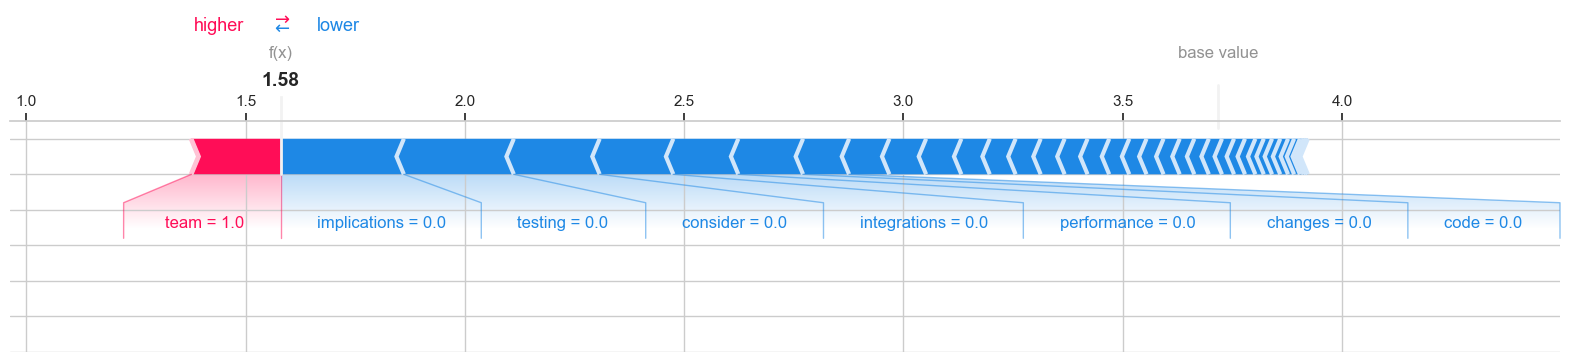


--- Explanation of the SHAP Force Plot ---
The plot above shows how each feature (word/term) contributed to the prediction for THIS specific description.
- The plot starts from the 'Base value' (the average prediction for training data).
- Features with red bars push the prediction HIGHER than the base value.
- Features with blue bars push the prediction LOWER than the base value.
- The length of each bar indicates the magnitude (strength) of the feature's impact.
- The plot path ends at the 'Output value' (the predicted story points for this specific description).
------------------------------------------
Predicted Story Points: 1.58
------------------------------------------


In [8]:
# --- Example Usage ---
new_story_description = """
I want to add optional contact preference details (like phone number and preferred contact method) to my profile
so that the support team can reach me more effectively if needed.
"""

# Call the function - the SHAP plot will be displayed below the cell by default
prediction = predict_story_points_with_explanation(new_story_description, show_explanation=True)

if isinstance(prediction, float):
    print(f"Predicted Story Points: {prediction:.2f}")
    print("------------------------------------------")
else:
    print(prediction)